# Lab 8: Representing Document Concepts with Embeddings 
## Team: Trojan Trio
## Member: Jinyao Yang, Qianshu Peng, Sen Pang

This notebook format was approved by TA Tanya via email for this assignment. A corresponding .py script containing only the code has also been provided
as requested.

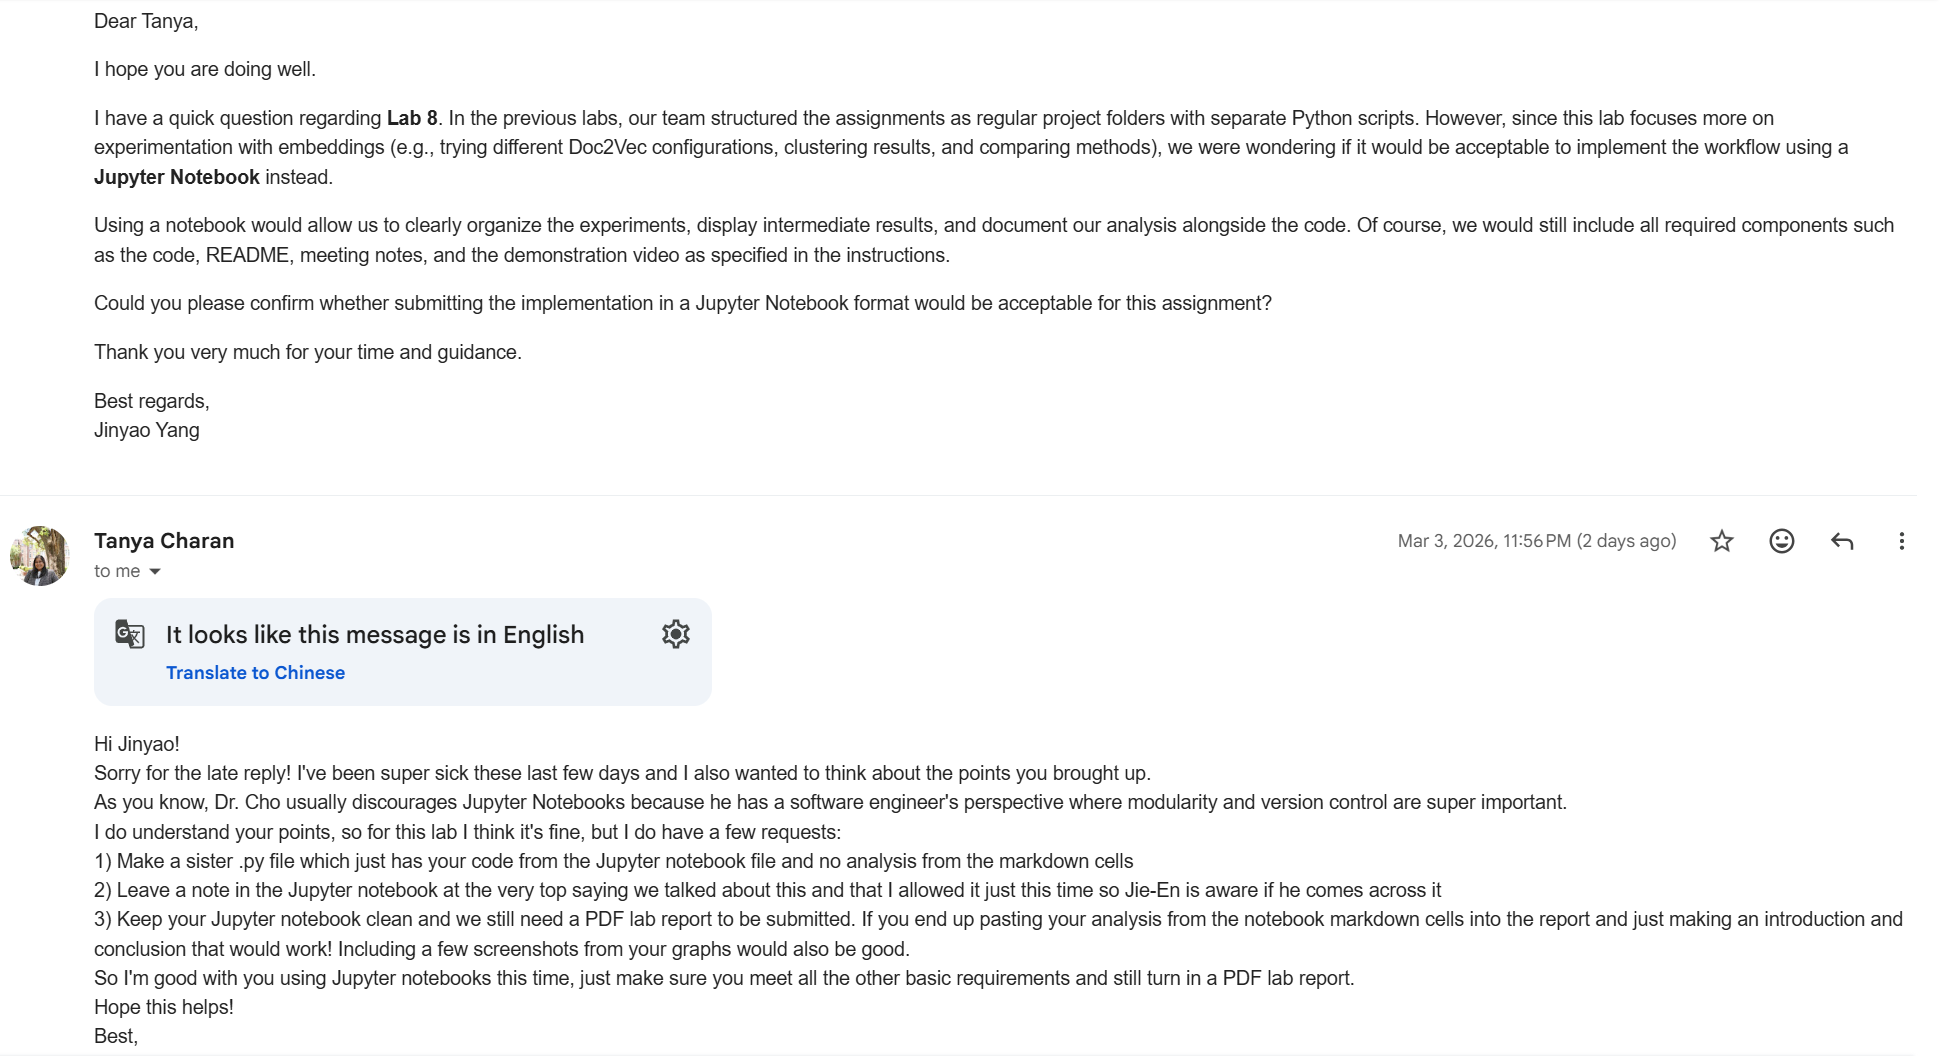

In [1]:
# Standard library
import json
import re
import html
from pathlib import Path
from itertools import product
from collections import Counter

# Data processing
import numpy as np
import pandas as pd

# Embedding models (Gensim)
from gensim.models import Word2Vec
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# Text processing / keyword extraction
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Clustering and evaluation
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## Load Data

In [ ]:
DATA_PATH = Path("data") / "posts_lab5_5000.json"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    posts = json.load(f)

assert isinstance(posts, list), "Expected a JSON list (array) of posts."
print("Total posts:", len(posts))


records = [
    p for p in posts
    if isinstance(p, dict)
    and isinstance(p.get("final_text"), str)
    and p.get("final_text").strip()
]

texts = [p["final_text"].strip() for p in records]

assert len(records) == len(texts), "records and texts are not aligned."

print("Non-empty texts:", len(texts))
print("Unique texts:", len(set(texts)), "/", len(texts))


sample = next((p for p in records if isinstance(p, dict)), None)
print("Sample keys:", list(sample.keys()) if sample else "EMPTY POSTS")


lengths = [len(t.split()) for t in texts]

if lengths:
    print("Min words:", min(lengths))
    print("Max words:", max(lengths))
    print("Average words:", sum(lengths) / len(lengths))
else:
    print("No non-empty texts found, cannot compute length stats.")

Total posts: 5000
Non-empty texts: 5000
Unique texts: 4938 / 5000
Sample keys: ['fullname', 'post_id', 'subreddit', 'title', 'author', 'author_raw', 'created_utc', 'created', 'permalink', 'out_url', 'domain', 'score', 'num_comments', 'is_self', 'body', 'final_text', 'is_image', 'is_gallery', 'image_url', 'gallery_urls', 'thumbnail', 'over_18', 'link_flair_text', 'ocr_text', 'keywords', 'topic']
Min words: 1
Max words: 4020
Average words: 72.6308


## Preprocessing

In [3]:
lengths = np.array([len(p.get("final_text","").split()) for p in posts])

print("p50:", np.percentile(lengths, 50))
print("p90:", np.percentile(lengths, 90))
print("p95:", np.percentile(lengths, 95))
print("p99:", np.percentile(lengths, 99))
print("max:", lengths.max())

p50: 21.0
p90: 191.0
p95: 272.0
p99: 563.0100000000002
max: 4020


In [4]:
TAG_RE = re.compile(r"<[^>]+>")
WS_RE  = re.compile(r"\s+")
URL_RE = re.compile(r"http\S+|www\.\S+")

def clean_text(text: str) -> str:
    """
    - html unescape
    - remove urls, html tags
    - remove zero-width/BOM chars
    - keep only a-z0-9 and whitespace
    - normalize whitespace
    """
    if not text:
        return ""

    text = html.unescape(text)
    text = URL_RE.sub(" ", text)
    text = TAG_RE.sub(" ", text)
    text = text.replace("\u200b", " ").replace("\ufeff", " ")
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = WS_RE.sub(" ", text).strip()
    return text

In [5]:
MIN_WORDS = 4
MAX_WORDS = 583

clean_records = []
tokenized_docs = []

dropped_short = 0
truncated_long = 0
empty_after_clean = 0

for p in posts:
    if not isinstance(p, dict):
        continue

    raw_text = p.get("final_text")
    if not raw_text:
        raw_text = (p.get("title", "") + " " + p.get("body", ""))

    text = clean_text(raw_text)

    if not text:
        empty_after_clean += 1
        continue

    toks = text.split()

    if len(toks) < MIN_WORDS:
        dropped_short += 1
        continue

    if len(toks) > MAX_WORDS:
        toks = toks[:MAX_WORDS]
        truncated_long += 1

    clean_records.append(p)
    tokenized_docs.append(toks)

assert len(clean_records) == len(tokenized_docs)

print("Documents:", len(tokenized_docs))
print("Dropped (too short):", dropped_short)
print("Empty after clean:", empty_after_clean)
print("Truncated (too long):", truncated_long)

lengths = [len(t) for t in tokenized_docs]

print("Min words:", min(lengths) if lengths else 0)
print("Max words:", max(lengths) if lengths else 0)
print("Average words:", (sum(lengths)/len(lengths)) if lengths else 0)

Documents: 4980
Dropped (too short): 4
Empty after clean: 16
Truncated (too long): 50
Min words: 4
Max words: 583
Average words: 68.53212851405623


## Global Utility

In [6]:
def evaluate_clustering(X_norm, labels):
    """X_norm must be L2-normalized."""
    n_clusters = len(set(labels))
    if n_clusters < 2:
        return {
            "silhouette": np.nan,
            "calinski_harabasz": np.nan,
            "davies_bouldin": np.nan
        }

    return {
        "silhouette": float(silhouette_score(X_norm, labels, metric="cosine")),
        "calinski_harabasz": float(calinski_harabasz_score(X_norm, labels)),
        "davies_bouldin": float(davies_bouldin_score(X_norm, labels)),
    }


def top_keywords_per_cluster(docs, labels, top_n=10, max_features=20000):
    """
    docs must be aligned with labels, e.g.:
    docs = [" ".join(doc) for doc in tokenized_docs]
    """
    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=max_features,
        ngram_range=(1, 2),
        min_df=3,
    )
    X = vectorizer.fit_transform(docs)
    terms = np.array(vectorizer.get_feature_names_out())

    out = {}
    labels = np.asarray(labels)

    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            out[int(c)] = []
            continue

        mean_scores = X[idx].mean(axis=0).A1
        top_idx = mean_scores.argsort()[::-1][:top_n]
        out[int(c)] = terms[top_idx].tolist()

    return out


def representative_docs(X_norm, labels, docs, per_cluster=3, records=None):
    """
    docs must be aligned with labels and records.
    Example:
    docs = [" ".join(doc) for doc in tokenized_docs]
    """
    labels = np.asarray(labels)
    reps = {}

    for c in sorted(set(labels)):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            reps[int(c)] = []
            continue

        centroid = X_norm[idx].mean(axis=0)
        centroid = centroid / (np.linalg.norm(centroid) + 1e-12)

        sims = X_norm[idx] @ centroid
        top_local = np.argsort(-sims)[:per_cluster]
        chosen = idx[top_local]

        out = []
        for j, i in enumerate(chosen):
            item = {
                "doc_index": int(i),
                "cosine_to_centroid": float(sims[top_local[j]]),
                "preview": " ".join(docs[i].split()[:40])
            }

            if records is not None:
                item["title"] = records[i].get("title", "")
                item["subreddit"] = records[i].get("subreddit", "")
                item["permalink"] = records[i].get("permalink", "")

            out.append(item)

        reps[int(c)] = out

    return reps


def save_pca_plot(X, labels, outpath, title):
    X = normalize(X, norm="l2")
    labels = np.asarray(labels)

    pca = PCA(n_components=2, random_state=42)
    X2 = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        X2[:, 0],
        X2[:, 1],
        s=8,
        c=labels,
        cmap="tab10",
        alpha=0.7
    )
    plt.colorbar(sc, label="Cluster")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.show()
    plt.close()


def show_cluster_samples(labels, docs, tokenized_docs, n=3, max_len=140):
    """
    docs must be aligned with tokenized_docs and labels.
    Example:
    docs = [" ".join(doc) for doc in tokenized_docs]
    """
    labels = np.asarray(labels)
    buckets = {}
    BAD_TOKENS = {"s", "t", "m", "ve", "re", "d", "ll", "1", "2", "3", "4", "0"}

    for i, c in enumerate(labels):
        buckets.setdefault(int(c), []).append(i)

    for c in sorted(buckets.keys()):
        idxs = buckets[c]
        print(f"\n=== Cluster {c} (size={len(idxs)}) ===")

        words = []
        for idx in idxs:
            words.extend([
                w for w in tokenized_docs[idx]
                if w not in ENGLISH_STOP_WORDS and w not in BAD_TOKENS
            ])

        top_words = Counter(words).most_common(10)
        print("Top words:", top_words)

        for idx in idxs[:n]:
            print("-", docs[idx][:max_len])


def compute_cluster_balance(labels):
    cluster_sizes = Counter(labels)
    size_values = list(cluster_sizes.values())

    return {
        "cluster_sizes": dict(cluster_sizes),
        "largest_cluster_ratio": max(size_values) / len(labels),
        "smallest_cluster_size": min(size_values),
        "num_tiny_clusters": sum(1 for s in size_values if s < 20),
        "std_cluster_size": float(np.std(size_values)),
    }


clean_texts = [" ".join(doc) for doc in tokenized_docs]

## Task 1: Doc2Vec Document Embedding and Clustering

In [7]:
tagged_docs = [
    TaggedDocument(words=doc, tags=[i])
    for i, doc in enumerate(tokenized_docs)
]

print("Sample TaggedDocument:", tagged_docs[0])

Sample TaggedDocument: TaggedDocument<['china', 's', 'new', 'five', 'year', 'plan', 'calls', 'for', 'ai', 'throughout', 'its', 'economy', 'tech', 'breakthroughs'], [0]>


In [8]:
def train_doc2vec_get_X(
    tagged_docs,
    vector_size,
    min_count,
    epochs,
    window=5,
    workers=1,
    dm=1,
    negative=5,
    hs=0,
    sample=1e-4,
    seed=42,
):
    model = Doc2Vec(
        vector_size=vector_size,
        min_count=min_count,
        window=window,
        workers=workers,
        dm=dm,
        negative=negative,
        hs=hs,
        sample=sample,
        seed=seed
    )

    model.build_vocab(tagged_docs)

    model.train(
        tagged_docs,
        total_examples=model.corpus_count,
        epochs=epochs
    )

    vectors = np.vstack([
        model.dv[i] for i in range(len(tagged_docs))
    ]).astype(np.float32)

    X = normalize(vectors, norm="l2")
    return model, vectors, X

In [9]:
K_FIXED = 8

doc2vec_configs = [
    {"name": "D1", "vector_size": 50,  "min_count": 2, "epochs": 20},
    {"name": "D2", "vector_size": 100, "min_count": 3, "epochs": 30},
    {"name": "D3", "vector_size": 200, "min_count": 5, "epochs": 40},
]

doc2vec_vs_results = []

for cfg in doc2vec_configs:

    print(f"\nRunning Doc2Vec {cfg['name']} | "
          f"vector_size={cfg['vector_size']}, "
          f"min_count={cfg['min_count']}, "
          f"epochs={cfg['epochs']}")

    model, vectors, X = train_doc2vec_get_X(
        tagged_docs,
        vector_size=cfg["vector_size"],
        min_count=cfg["min_count"],
        epochs=cfg["epochs"],
        dm=1,
        seed=42,
        workers=1
    )

    km = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
    labels = km.fit_predict(X)

    metrics = evaluate_clustering(X, labels)
    balance = compute_cluster_balance(labels)

    doc2vec_vs_results.append({
        "config": cfg["name"],
        "vector_size": cfg["vector_size"],
        "min_count": cfg["min_count"],
        "epochs": cfg["epochs"],
        "silhouette_cosine": metrics["silhouette"],
        "calinski_harabasz": metrics["calinski_harabasz"],
        "davies_bouldin": metrics["davies_bouldin"],
        "largest_cluster_ratio": balance["largest_cluster_ratio"],
        "smallest_cluster_size": balance["smallest_cluster_size"],
        "num_tiny_clusters": balance["num_tiny_clusters"],
        "std_cluster_size": balance["std_cluster_size"],
    })

df_doc2vec_vs = pd.DataFrame(doc2vec_vs_results).sort_values(
    by=["silhouette_cosine", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n=== Doc2Vec configuration comparison ===")
display(df_doc2vec_vs)


Running Doc2Vec D1 | vector_size=50, min_count=2, epochs=20


D:\python\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\python\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "D:\python\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\python\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "D:\python\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^


Running Doc2Vec D2 | vector_size=100, min_count=3, epochs=30


D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(



Running Doc2Vec D3 | vector_size=200, min_count=5, epochs=40


D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(



=== Doc2Vec configuration comparison ===


,config,vector_size,min_count,epochs,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size
0,D1,50,2,20,0.258454,900.381916,1.756644,0.400000,150,0,569.251482
1,D2,100,3,30,0.185912,618.681777,1.949999,0.242169,229,0,342.166626
2,D3,200,5,40,0.148541,434.385052,2.244491,0.230120,347,0,251.250871


We tested three representative Doc2Vec configurations with different embedding dimensions and training settings: D1 (vector_size=50, min_count=2, epochs=20), D2 (vector_size=100, min_count=3, epochs=30), and D3 (vector_size=200, min_count=5, epochs=40). For each configuration, document embeddings were generated, L2-normalized, clustered using KMeans (k=8), and evaluated with cosine Silhouette Score, Calinski–Harabasz Index, and Davies–Bouldin Index.

Among these three initial configurations, D1 showed the strongest overall clustering performance. It achieved the highest Silhouette Score and Calinski–Harabasz Index, as well as the lowest Davies–Bouldin Index, indicating more compact and better-separated clusters than D2 and D3. This suggests that, in our preliminary comparison, the lower-dimensional Doc2Vec setting was more effective for representing the Reddit posts for clustering. Since only three representative configurations were tested at this stage, D1 was selected as the best preliminary Doc2Vec configuration rather than the definitive final model.

D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


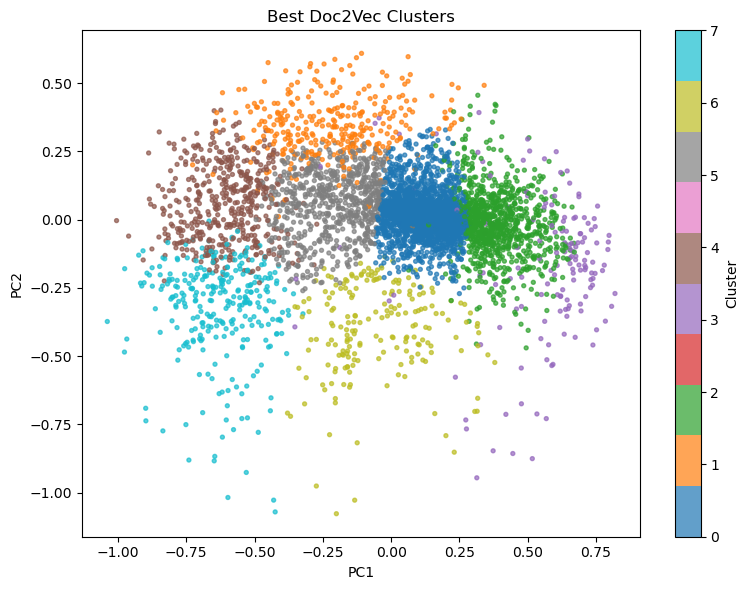


=== Cluster 0 (size=1992) ===
Top words: [('ai', 501), ('new', 232), ('data', 214), ('just', 147), ('like', 139), ('use', 97), ('model', 89), ('using', 81), ('security', 81), ('time', 79)]
- china s new five year plan calls for ai throughout its economy tech breakthroughs
- wood polymer gives thermal paper an eco friendly makeover
- dissolvable hydrogel could enable personalized bone implants

=== Cluster 1 (size=319) ===
Top words: [('ai', 307), ('like', 250), ('just', 211), ('use', 135), ('data', 122), ('code', 121), ('don', 120), ('know', 118), ('time', 110), ('think', 108)]
- models that improve on their own are ai s next big thing
- building the world s first open source quantum computer
- with so many people using ai agents it seems there is a rise in steganography for prompt injections i have seen ai agents meant to summarize

=== Cluster 2 (size=912) ===
Top words: [('ai', 388), ('data', 191), ('new', 150), ('agent', 122), ('security', 114), ('just', 111), ('like', 96), ('5', 

In [10]:
best_cfg = {"name": "D1", "vector_size": 50, "min_count": 2, "epochs": 20}

model, vectors, X = train_doc2vec_get_X(
    tagged_docs,
    vector_size=best_cfg["vector_size"],
    min_count=best_cfg["min_count"],
    epochs=best_cfg["epochs"],
    dm=1,
    seed=42,
    workers=1
)

kmeans = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

top_words = top_keywords_per_cluster(clean_texts, labels, top_n=10)
reps = representative_docs(X, labels, clean_texts, per_cluster=3, records=clean_records)

save_pca_plot(vectors, labels, "doc2vec_best_pca.png", "Best Doc2Vec Clusters")
show_cluster_samples(labels, clean_texts, tokenized_docs, n=3)

### Doc2Vec Clustering Results and Analysis

The clustering results reveal several partially interpretable themes within the Reddit dataset. Cluster 0 contains a large proportion of general technology- and AI-related posts, as reflected by frequent keywords such as *ai*, *data*, and *model*, but it is also relatively broad and heterogeneous. Cluster 4 and Cluster 7 appear relatively more coherent, with many posts related to careers, jobs, data science, machine learning, and cybersecurity. In contrast, some other clusters, such as Cluster 2 and Cluster 5, are less clearly differentiated and include a mixture of science, technology, and discovery-oriented topics.

Overall, the Doc2Vec embeddings capture some meaningful topical structure, but the semantic coherence is uneven across clusters. The PCA visualization also suggests partial separation rather than fully distinct boundaries, and the presence of one dominant large cluster indicates that the clustering remains somewhat imbalanced. These observations suggest that while Doc2Vec is useful for organizing the Reddit posts semantically, its performance may still be improved through additional hyperparameter tuning.

To obtain a more reliable understanding of how Doc2Vec hyperparameters affect clustering quality, we conducted a broader grid search over embedding dimensionality, minimum word count, training epochs, and training mode (`dm`).

In [11]:
docs = [" ".join(toks) for toks in tokenized_docs]
records = clean_records

vector_size_grid = [50, 100, 200]
min_count_grid = [2, 3, 5]
epochs_grid = [10, 20, 30, 40]
dm_grid = [0, 1]

task1_search_results = []

for vs, mc, ep, dm in product(vector_size_grid, min_count_grid, epochs_grid, dm_grid):
    print(f"Running: vector_size={vs}, min_count={mc}, epochs={ep}, dm={dm}")

    model, vectors, X = train_doc2vec_get_X(
        tagged_docs,
        vector_size=vs,
        min_count=mc,
        epochs=ep,
        dm=dm,
        seed=42,
        workers=1
    )

    kmeans = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    metrics = evaluate_clustering(X, labels)
    balance = compute_cluster_balance(labels)
    top_words = top_keywords_per_cluster(docs, labels, top_n=10)
    reps = representative_docs(X, labels, docs, per_cluster=3, records=records)

    task1_search_results.append({
        "vector_size": vs,
        "min_count": mc,
        "epochs": ep,
        "dm": dm,

        "model": model,
        "vectors": vectors,
        "X": X,
        "labels": labels,

        "silhouette_cosine": metrics["silhouette"],
        "calinski_harabasz": metrics["calinski_harabasz"],
        "davies_bouldin": metrics["davies_bouldin"],

        "cluster_sizes": balance["cluster_sizes"],
        "largest_cluster_ratio": balance["largest_cluster_ratio"],
        "smallest_cluster_size": balance["smallest_cluster_size"],
        "num_tiny_clusters": balance["num_tiny_clusters"],
        "std_cluster_size": balance["std_cluster_size"],

        "top_words": top_words,
        "representative_docs": reps,
    })

df_task1_search = pd.DataFrame([
    {
        "vector_size": r["vector_size"],
        "min_count": r["min_count"],
        "epochs": r["epochs"],
        "dm": r["dm"],
        "silhouette_cosine": r["silhouette_cosine"],
        "calinski_harabasz": r["calinski_harabasz"],
        "davies_bouldin": r["davies_bouldin"],
        "largest_cluster_ratio": r["largest_cluster_ratio"],
        "smallest_cluster_size": r["smallest_cluster_size"],
        "num_tiny_clusters": r["num_tiny_clusters"],
        "std_cluster_size": r["std_cluster_size"],
    }
    for r in task1_search_results
])

df_task1_search = df_task1_search.sort_values(
    by=["silhouette_cosine", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

df_task1_search["is_degenerate"] = (
    (df_task1_search["largest_cluster_ratio"] > 0.7) |
    (df_task1_search["smallest_cluster_size"] < 20) |
    (df_task1_search["num_tiny_clusters"] > 0)
)

print("\n=== All Doc2Vec search results ===")
display(df_task1_search)

Running: vector_size=50, min_count=2, epochs=10, dm=0


D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Running: vector_size=50, min_count=2, epochs=10, dm=1


D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Running: vector_size=50, min_count=2, epochs=20, dm=0


...

D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Running: vector_size=200, min_count=5, epochs=40, dm=1


D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(



=== All Doc2Vec search results ===


,vector_size,min_count,epochs,dm,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size,is_degenerate
0,200,3,10,1,0.807555,708.887107,3.253647,0.918072,7,1,1493.532808,True
1,200,3,20,0,0.557908,678.291172,1.741499,0.692169,32,0,1090.789851,False
2,200,5,20,0,0.536364,690.479247,1.848525,0.692369,36,0,1081.280260,False
3,200,2,20,0,0.532292,673.869950,1.851223,0.684940,32,0,1070.800752,False
4,100,3,20,0,0.365233,581.504926,1.942886,0.609839,32,0,941.983413,False
...,...,...,...,...,...,...,...,...,...,...,...,...
67,50,3,10,0,0.032870,127.220056,3.369855,0.463253,4,2,791.442038,True
68,50,2,10,0,0.027449,137.452218,3.463046,0.348996,4,2,718.744217,True
69,200,3,10,0,0.026056,138.484020,2.808386,0.743574,1,3,1201.522888,True
70,50,5,10,0,0.023623,130.971581,3.550807,0.376707,4,2,729.441396,True


In [12]:
df_metric_ranked = df_task1_search.sort_values(
    by=["silhouette_cosine", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n=== Metric-best ranking ===")
display(df_metric_ranked.head(10))

best_metric_row = df_metric_ranked.iloc[0]

best_metric_result = next(
    r for r in task1_search_results
    if r["vector_size"] == best_metric_row["vector_size"]
    and r["min_count"] == best_metric_row["min_count"]
    and r["epochs"] == best_metric_row["epochs"]
    and r["dm"] == best_metric_row["dm"]
)

print("\n=== Best model by internal metrics ===")
print(best_metric_row)

print("\nCluster sizes (metric-best):")
print(best_metric_result["cluster_sizes"])


=== Metric-best ranking ===


,vector_size,min_count,epochs,dm,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size,is_degenerate
0,200,3,10,1,0.807555,708.887107,3.253647,0.918072,7,1,1493.532808,True
1,200,3,20,0,0.557908,678.291172,1.741499,0.692169,32,0,1090.789851,False
2,200,5,20,0,0.536364,690.479247,1.848525,0.692369,36,0,1081.280260,False
3,200,2,20,0,0.532292,673.869950,1.851223,0.684940,32,0,1070.800752,False
4,100,3,20,0,0.365233,581.504926,1.942886,0.609839,32,0,941.983413,False
5,200,2,20,1,0.328522,1303.037887,1.399821,0.380120,34,0,565.097116,False
6,200,3,20,1,0.309461,1268.660174,1.395099,0.359639,170,0,516.726717,False
7,200,2,10,1,0.300805,809.726073,3.265632,0.803815,12,1,1292.194548,True
8,200,2,10,0,0.293014,146.920245,1.674070,0.871084,1,4,1412.833147,True
9,200,5,10,1,0.292161,578.494639,3.492466,0.795984,8,1,1276.955853,True



=== Best model by internal metrics ===
vector_size                      200
min_count                          3
epochs                            10
dm                                 1
silhouette_cosine           0.807555
calinski_harabasz         708.887107
davies_bouldin              3.253647
largest_cluster_ratio       0.918072
smallest_cluster_size              7
num_tiny_clusters                  1
std_cluster_size         1493.532808
is_degenerate                   True
Name: 0, dtype: object

Cluster sizes (metric-best):
{0: 4572, 5: 176, 2: 69, 1: 31, 3: 37, 4: 44, 7: 44, 6: 7}


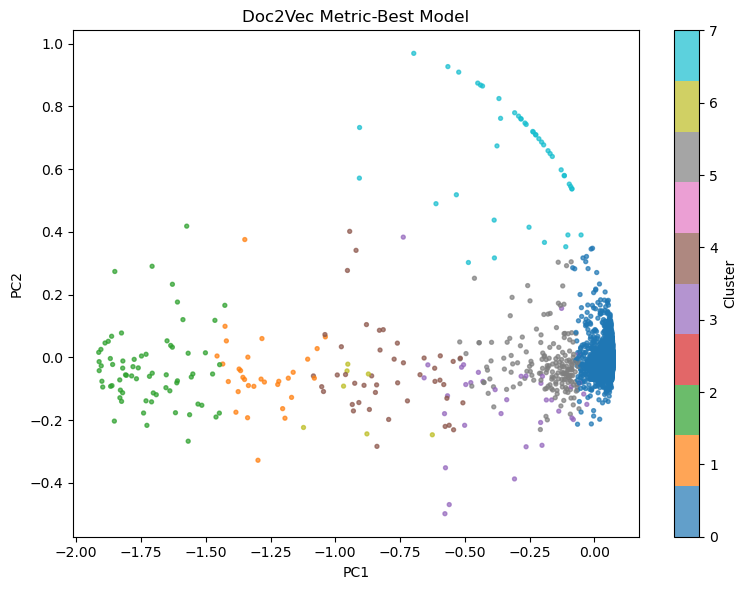


=== Metric-best cluster samples ===

=== Cluster 0 (size=4572) ===
Top words: [('ai', 1717), ('data', 1481), ('like', 1240), ('just', 1066), ('new', 652), ('work', 652), ('time', 649), ('use', 592), ('security', 536), ('know', 535)]
- china s new five year plan calls for ai throughout its economy tech breakthroughs
- wood polymer gives thermal paper an eco friendly makeover
- scientists discover plant compound that forces aggressive breast cancer cells into self destruction

=== Cluster 1 (size=31) ===
Top words: [('ai', 14), ('ceo', 5), ('says', 5), ('google', 5), ('job', 5), ('time', 4), ('tech', 4), ('researchers', 3), ('results', 3), ('got', 3)]
- researchers build a stretchable oled that can double in size without dimming
- nvidia ceo huang says 30 billion openai investment might be the last
- google is blocking ai searches for the president and dementia google appears to have blocked ai search results for questions about his menta

=== Cluster 2 (size=69) ===
Top words: [('ai', 

In [13]:
save_pca_plot(
    best_metric_result["X"],
    best_metric_result["labels"],
    "doc2vec_metric_best.png",
    "Doc2Vec Metric-Best Model"
)

print("\n=== Metric-best cluster samples ===")
show_cluster_samples(
    best_metric_result["labels"],
    docs,
    tokenized_docs,
    n=3
)

### Raw Metric-Best Doc2Vec Result

After ranking all Doc2Vec grid-search configurations by cosine Silhouette Score, Calinski–Harabasz Index, and Davies–Bouldin Index, the top-ranked model was `vector_size=200`, `min_count=3`, `epochs=10`, and `dm=1`. This configuration achieved the highest cosine Silhouette Score among all tested settings.

However, further inspection showed that this model was highly degenerate. It assigned 4,572 out of 4,980 documents to a single cluster, leaving the remaining documents distributed across several very small clusters, with the smallest cluster containing only 7 documents. The PCA visualization also confirmed this pattern, showing one dominant dense cluster and a few scattered peripheral groups.

Although this configuration ranked first by internal clustering metrics, its cluster structure was not semantically desirable. The dominant cluster was overly broad and heterogeneous, absorbing most of the dataset into a single group rather than producing a balanced and interpretable semantic partition. This result shows that internal metrics alone can be misleading for model selection. Therefore, we did not treat this raw metric-best configuration as the final Doc2Vec choice, and instead continued the analysis using non-degenerate models with more balanced cluster structures.

In [14]:
df_reasonable = df_task1_search[
    (df_task1_search["largest_cluster_ratio"] < 0.50) &
    (df_task1_search["num_tiny_clusters"] == 0) &
    (df_task1_search["smallest_cluster_size"] >= 30) &
    (df_task1_search["silhouette_cosine"] >= 0.20)
].copy()

df_semantic_ranked = df_reasonable.sort_values(
    by=[
        "silhouette_cosine",
        "calinski_harabasz",
        "davies_bouldin",
        "largest_cluster_ratio",
        "std_cluster_size"
    ],
    ascending=[False, False, True, True, True]
).reset_index(drop=True)

print("\n=== Semantic candidate ranking ===")
display(df_semantic_ranked.head(10))


=== Semantic candidate ranking ===


,vector_size,min_count,epochs,dm,silhouette_cosine,calinski_harabasz,davies_bouldin,largest_cluster_ratio,smallest_cluster_size,num_tiny_clusters,std_cluster_size,is_degenerate
0,200,2,20,1,0.328522,1303.037887,1.399821,0.380120,34,0,565.097116,False
1,200,3,20,1,0.309461,1268.660174,1.395099,0.359639,170,0,516.726717,False
2,100,3,20,1,0.265784,1054.674442,1.570071,0.356827,174,0,506.244259,False
3,100,2,20,1,0.263260,1056.000512,1.605762,0.357430,46,0,539.940969,False
4,200,5,20,1,0.258820,1184.561823,1.473625,0.327309,189,0,479.930724,False
5,50,2,20,1,0.258454,900.381916,1.756644,0.400000,150,0,569.251482,False
6,100,5,20,1,0.218291,986.068750,1.632594,0.321687,214,0,467.846396,False
7,50,3,20,1,0.215057,878.418530,1.727379,0.331124,210,0,480.616791,False
8,200,5,30,1,0.213114,661.664025,1.823753,0.290763,201,0,429.112165,False
9,50,5,20,1,0.209841,815.947681,1.760456,0.327309,202,0,495.257004,False



Semantic candidate: {'vector_size': 200, 'min_count': 2, 'epochs': 20, 'dm': 1}
silhouette=0.3285, CH=1303.04, DB=1.3998
Cluster sizes: {3: 1080, 1: 1893, 7: 263, 0: 34, 6: 638, 4: 315, 2: 234, 5: 523}

Top keywords by cluster:
Cluster 0: ['ai', 'nvidia', 'says', 'ceo', 'china', 'anthropic', 'claude', 'companies', 'trump', 'ai says']
Cluster 1: ['ai', 'new', 'data', 'says', 'just', 'use', 'like', 'tech', 'scientists', 'using']
Cluster 2: ['data', 'books', 'science', 'computer', 'job', 'like', 'ml', 'resources', 'learning', 'know']
Cluster 3: ['ai', 'new', 'trump', 'says', 'data', 'openai', '000', 'anthropic', 'google', 'billion']
Cluster 4: ['data', 'learning', 'questions', 'search', 'education', 'science', 'online', 'resources', 'thread', 'answers']
Cluster 5: ['like', 'data', 'just', 'work', 've', 'know', 'don', 'want', 'people', 'job']
Cluster 6: ['ai', 'like', 'just', 've', 'use', 'know', 'think', 'does', 'time', 'don']
Cluster 7: ['ai', 'anthropic', 'trump', 'openai', 'new', 'pen

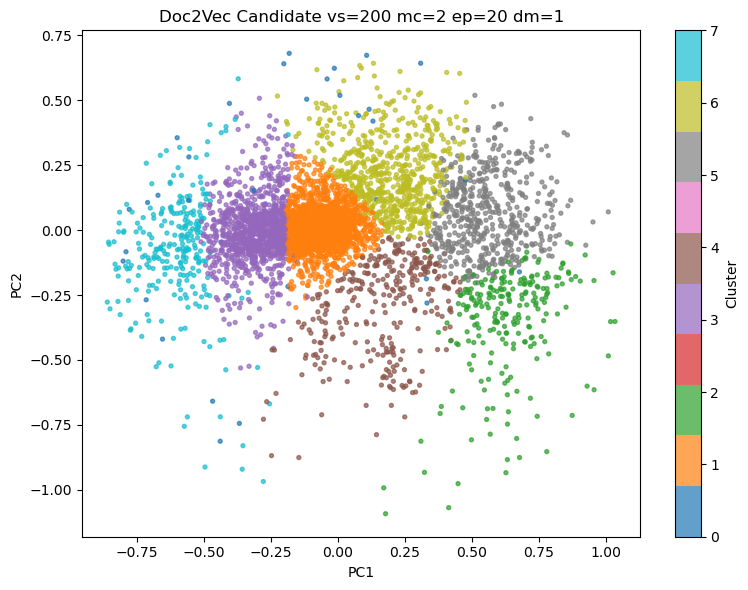


Cluster samples:

=== Cluster 0 (size=34) ===
Top words: [('ai', 22), ('nvidia', 7), ('just', 6), ('says', 6), ('china', 5), ('claude', 5), ('did', 5), ('anthropic', 5), ('ceo', 5), ('companies', 4)]
- models that improve on their own are ai s next big thing
- i always read about bots scanning the internet but what does it really mean do they just incrementing from 0 0 0 0 or they have specific ran
- china just used claude to hack 30 companies the ai did 90 of the work anthropic caught them and is telling everyone how they did it

=== Cluster 1 (size=1893) ===
Top words: [('ai', 446), ('new', 207), ('data', 179), ('like', 136), ('just', 130), ('use', 94), ('using', 87), ('people', 70), ('security', 70), ('model', 69)]
- wood polymer gives thermal paper an eco friendly makeover
- dissolvable hydrogel could enable personalized bone implants
- radical winter tires automatically deploy retractable studs for traction on icy roads

=== Cluster 2 (size=234) ===
Top words: [('data', 266), ('l

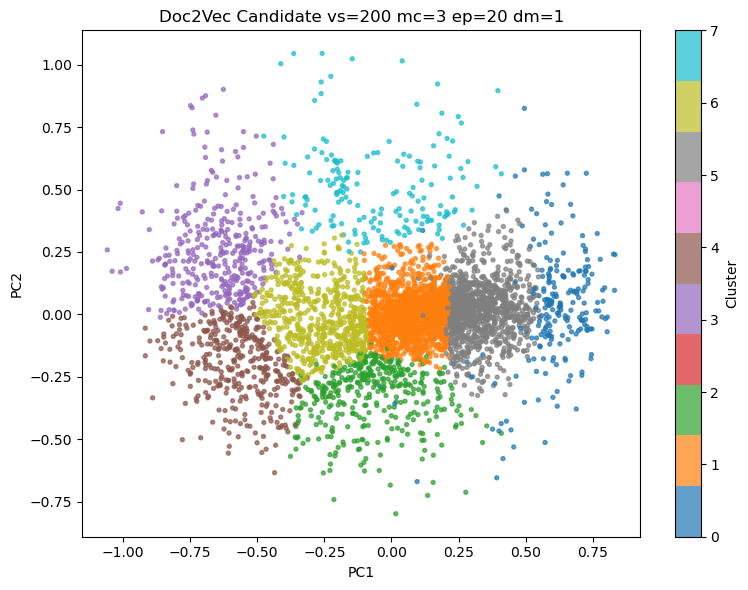


Cluster samples:

=== Cluster 0 (size=222) ===
Top words: [('ai', 197), ('agent', 94), ('data', 93), ('new', 67), ('access', 59), ('security', 56), ('agents', 54), ('google', 53), ('code', 50), ('5', 48)]
- human brain cells on a chip learned to play doom in a week
- brain inspired chip is helping robots to see faster and in real time
- sixteen claude ai agents working together created a new c compiler

=== Cluster 1 (size=1791) ===
Top words: [('ai', 423), ('new', 185), ('data', 172), ('like', 119), ('just', 104), ('use', 81), ('using', 80), ('security', 67), ('world', 64), ('models', 64)]
- china s new five year plan calls for ai throughout its economy tech breakthroughs
- wood polymer gives thermal paper an eco friendly makeover
- dissolvable hydrogel could enable personalized bone implants

=== Cluster 2 (size=383) ===
Top words: [('ai', 351), ('just', 211), ('like', 208), ('data', 120), ('use', 116), ('don', 112), ('code', 110), ('know', 105), ('time', 101), ('think', 90)]
- mode

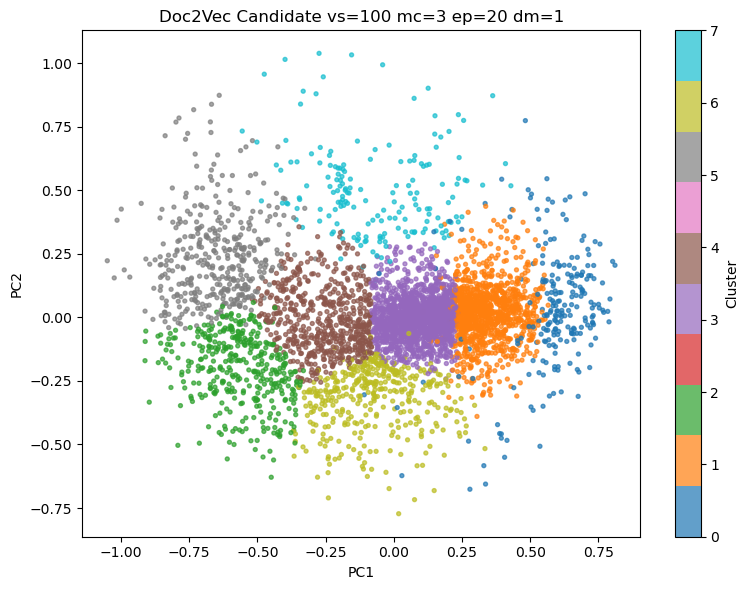


Cluster samples:

=== Cluster 0 (size=228) ===
Top words: [('ai', 196), ('agent', 94), ('data', 93), ('new', 68), ('access', 59), ('security', 56), ('agents', 54), ('code', 50), ('google', 50), ('use', 49)]
- human brain cells on a chip learned to play doom in a week
- brain inspired chip is helping robots to see faster and in real time
- sixteen claude ai agents working together created a new c compiler

=== Cluster 1 (size=1059) ===
Top words: [('ai', 391), ('data', 185), ('new', 170), ('just', 123), ('like', 102), ('security', 98), ('model', 83), ('trump', 81), ('says', 80), ('time', 76)]
- scientists discover plant compound that forces aggressive breast cancer cells into self destruction
- new toothpaste stops gum disease without harming healthy bacteria
- device that can extract 1 000 liters of clean water a day from desert air revealed by 2025 nobel prize winner claimed to work in desert air 

=== Cluster 2 (size=384) ===
Top words: [('like', 380), ('just', 308), ('data', 255), 

In [15]:
top_semantic_candidates = df_semantic_ranked.head(3).to_dict("records")

semantic_candidates_results = []

for row in top_semantic_candidates:
    cfg = {
        "vector_size": int(row["vector_size"]),
        "min_count": int(row["min_count"]),
        "epochs": int(row["epochs"]),
        "dm": int(row["dm"]),
    }

    result = next(
        r for r in task1_search_results
        if r["vector_size"] == cfg["vector_size"]
        and r["min_count"] == cfg["min_count"]
        and r["epochs"] == cfg["epochs"]
        and r["dm"] == cfg["dm"]
    )

    semantic_candidates_results.append((cfg, result))

    print("\n" + "=" * 80)
    print("Semantic candidate:", cfg)
    print(
        f"silhouette={result['silhouette_cosine']:.4f}, "
        f"CH={result['calinski_harabasz']:.2f}, "
        f"DB={result['davies_bouldin']:.4f}"
    )
    print("Cluster sizes:", result["cluster_sizes"])

    print("\nTop keywords by cluster:")
    for c, kws in result["top_words"].items():
        print(f"Cluster {c}: {kws}")

    print("\nRepresentative docs by cluster:")
    for c, items in result["representative_docs"].items():
        print(f"\nCluster {c}")
        for item in items:
            title = item.get("title", "")
            preview = item.get("preview", "")
            print(f"- {title} | {preview}")

    save_pca_plot(
        result["X"],
        result["labels"],
        f"doc2vec_semantic_candidate_vs{cfg['vector_size']}_mc{cfg['min_count']}_ep{cfg['epochs']}_dm{cfg['dm']}.png",
        f"Doc2Vec Candidate vs={cfg['vector_size']} mc={cfg['min_count']} ep={cfg['epochs']} dm={cfg['dm']}"
    )

    print("\nCluster samples:")
    show_cluster_samples(
        result["labels"],
        docs,
        tokenized_docs,
        n=3
    )

### Qualitative Review of Top Semantic Candidates

To identify the semantic-best Doc2Vec model, we first excluded clearly degenerate or poorly balanced configurations by requiring a largest cluster ratio below 0.50, no tiny clusters, a minimum cluster size of at least 30, and a cosine Silhouette Score of at least 0.20. The remaining models were then ranked by a combination of clustering quality and balance criteria, including cosine Silhouette Score, Calinski–Harabasz Index, Davies–Bouldin Index, largest cluster ratio, and cluster-size dispersion.

From this filtered ranking, we selected the top three candidates for closer qualitative inspection. We compared their cluster sizes, top keywords, representative documents, PCA visualizations, and sample posts to judge semantic coherence and interpretability. Although `(200, 2, 20, 1)` had the strongest quantitative performance among these candidates, its clustering structure was still somewhat uneven. In contrast, `(200, 3, 20, 1)` provided a better balance between cluster quality, size distribution, and thematic clarity. Its clusters were more evenly distributed and showed clearer interpretable themes, such as AI and technology news, career and education discussions, and more general technical question-oriented content. Therefore, we selected `(200, 3, 20, 1)` as the semantic-best Doc2Vec configuration.

In [16]:
semantic_choice_d2v = {
    "vector_size": 200,
    "min_count": 3,
    "epochs": 20,
    "dm": 1
}

best_semantic_d2v_result = next(
    r for r in task1_search_results
    if r["vector_size"] == semantic_choice_d2v["vector_size"]
    and r["min_count"] == semantic_choice_d2v["min_count"]
    and r["epochs"] == semantic_choice_d2v["epochs"]
    and r["dm"] == semantic_choice_d2v["dm"]
)

print("\n=== Final semantic-best Doc2Vec model ===")
print(semantic_choice_d2v)
print("Cluster sizes:", best_semantic_d2v_result["cluster_sizes"])


=== Final semantic-best Doc2Vec model ===
{'vector_size': 200, 'min_count': 3, 'epochs': 20, 'dm': 1}
Cluster sizes: {1: 1791, 5: 1086, 0: 222, 7: 170, 2: 383, 6: 598, 3: 358, 4: 372}


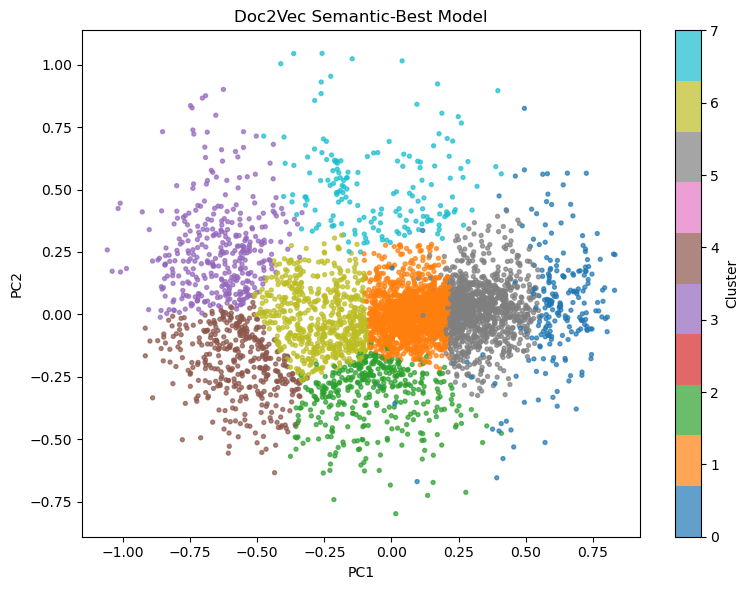


=== Cluster 0 (size=222) ===
Top words: [('ai', 197), ('agent', 94), ('data', 93), ('new', 67), ('access', 59), ('security', 56), ('agents', 54), ('google', 53), ('code', 50), ('5', 48)]
- human brain cells on a chip learned to play doom in a week
- brain inspired chip is helping robots to see faster and in real time
- sixteen claude ai agents working together created a new c compiler

=== Cluster 1 (size=1791) ===
Top words: [('ai', 423), ('new', 185), ('data', 172), ('like', 119), ('just', 104), ('use', 81), ('using', 80), ('security', 67), ('world', 64), ('models', 64)]
- china s new five year plan calls for ai throughout its economy tech breakthroughs
- wood polymer gives thermal paper an eco friendly makeover
- dissolvable hydrogel could enable personalized bone implants

=== Cluster 2 (size=383) ===
Top words: [('ai', 351), ('just', 211), ('like', 208), ('data', 120), ('use', 116), ('don', 112), ('code', 110), ('know', 105), ('time', 101), ('think', 90)]
- models that improve on

In [17]:
save_pca_plot(
    best_semantic_d2v_result["X"],
    best_semantic_d2v_result["labels"],
    "doc2vec_semantic_best.png",
    "Doc2Vec Semantic-Best Model"
)

show_cluster_samples(
    best_semantic_d2v_result["labels"],
    docs,
    tokenized_docs,
    n=3
)

## Task 2: Word2Vec-Based Document Representation and Clustering

In [18]:
sentences = tokenized_docs   # list[list[str]]
print("Number of sentences:", len(sentences))

Number of sentences: 4980


In [19]:
def cluster_words_into_bins(word_vecs, k):
    word_vecs_norm = normalize(word_vecs, norm="l2")

    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    word_labels = km.fit_predict(word_vecs_norm)

    return word_labels


def build_word_to_bin(words, word_labels):
    assert len(words) == len(word_labels), "words and word_labels are not aligned."
    return {w: int(lbl) for w, lbl in zip(words, word_labels)}


def docs_to_bin_freq_vectors(tokenized_docs, word_to_bin, k):
    X = np.zeros((len(tokenized_docs), k), dtype=np.float32)
    zero_doc_count = 0

    for i, tokens in enumerate(tokenized_docs):
        count = 0

        for tok in tokens:
            if tok in word_to_bin:
                X[i, word_to_bin[tok]] += 1.0
                count += 1

        if count > 0:
            X[i] /= count
        else:
            zero_doc_count += 1

    return X, zero_doc_count

In [20]:
def train_word2vec_get_wordvecs(
    sentences,
    vector_size,
    min_count,
    epochs,
    window=5,
    workers=1,
    sg=0,
    negative=5,
    hs=0,
    sample=1e-4,
    seed=42,
):
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        min_count=min_count,
        window=window,
        workers=workers,
        sg=sg,
        negative=negative,
        hs=hs,
        sample=sample,
        seed=seed,
        epochs=epochs
    )

    words = list(model.wv.index_to_key)
    word_vecs = np.vstack([model.wv[w] for w in words]).astype(np.float32)

    return model, words, word_vecs

In [21]:
w2v_baseline_configs = [
    {"name": "W1", "vector_size": 50,  "min_count": 2, "epochs": 20, "sg": 0},
    {"name": "W2", "vector_size": 100, "min_count": 3, "epochs": 30, "sg": 0},
    {"name": "W3", "vector_size": 200, "min_count": 5, "epochs": 40, "sg": 0},
]

w2v_models = {}

for cfg in w2v_baseline_configs:
    print(
        f"\nTraining Word2Vec {cfg['name']} | "
        f"vector_size={cfg['vector_size']}, "
        f"min_count={cfg['min_count']}, "
        f"epochs={cfg['epochs']}, "
        f"sg={cfg['sg']}"
    )

    model, words, word_vecs = train_word2vec_get_wordvecs(
        sentences=sentences,
        vector_size=cfg["vector_size"],
        min_count=cfg["min_count"],
        epochs=cfg["epochs"],
        sg=cfg["sg"],
        workers=1,
        seed=42
    )

    w2v_models[cfg["name"]] = {
        "config": cfg,
        "model": model,
        "words": words,
        "word_vecs": word_vecs
    }

    print("Vocab size:", len(words))
    print("Word vector shape:", word_vecs.shape)


Training Word2Vec W1 | vector_size=50, min_count=2, epochs=20, sg=0
Vocab size: 11250
Word vector shape: (11250, 50)

Training Word2Vec W2 | vector_size=100, min_count=3, epochs=30, sg=0
Vocab size: 8460
Word vector shape: (8460, 100)

Training Word2Vec W3 | vector_size=200, min_count=5, epochs=40, sg=0
Vocab size: 5927
Word vector shape: (5927, 200)


Zero-vector docs: 0


D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


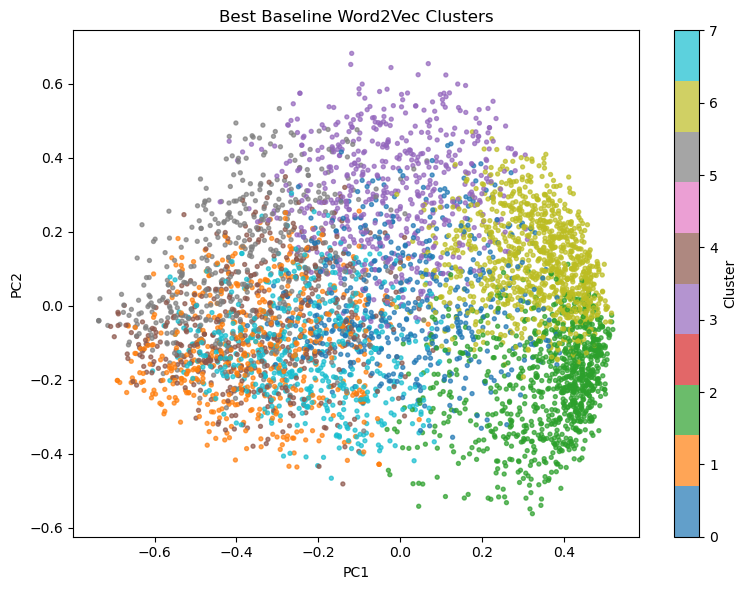


=== Cluster 0 (size=494) ===
Top words: [('ai', 163), ('use', 62), ('like', 51), ('new', 47), ('make', 42), ('data', 33), ('need', 27), ('using', 26), ('does', 25), ('think', 25)]
- teens invent condom that changes color when it detects an sti
- low noise microwave amplifiers bring quantum computers closer to scale
- scientists discovered an organism that can become two different life forms

=== Cluster 1 (size=513) ===
Top words: [('new', 168), ('ai', 93), ('cancer', 61), ('cells', 52), ('brain', 45), ('report', 44), ('drug', 42), ('data', 38), ('breakthrough', 33), ('scientists', 31)]
- scientists discover plant compound that forces aggressive breast cancer cells into self destruction
- new toothpaste stops gum disease without harming healthy bacteria
- device that can extract 1 000 liters of clean water a day from desert air revealed by 2025 nobel prize winner claimed to work in desert air 

=== Cluster 2 (size=892) ===
Top words: [('data', 640), ('like', 472), ('just', 345), ('wor

In [24]:
best_w2v_cfg = {"name": "W1", "vector_size": 50, "min_count": 2, "epochs": 20, "sg": 0}
num_bins = best_w2v_cfg["vector_size"]

# 1) train Word2Vec
model, words, word_vecs = train_word2vec_get_wordvecs(
    sentences=sentences,
    vector_size=best_w2v_cfg["vector_size"],
    min_count=best_w2v_cfg["min_count"],
    epochs=best_w2v_cfg["epochs"],
    sg=best_w2v_cfg["sg"],
    workers=1,
    seed=42
)

# 2) cluster words into semantic bins
word_labels = cluster_words_into_bins(word_vecs, num_bins)
word_to_bin = build_word_to_bin(words, word_labels)

# 3) convert documents to normalized bin-frequency vectors
X_doc, zero_doc_count = docs_to_bin_freq_vectors(tokenized_docs, word_to_bin, num_bins)
print("Zero-vector docs:", zero_doc_count)

X_doc = normalize(X_doc, norm="l2")

# 4) drop zero vectors if any
row_norms = np.linalg.norm(X_doc, axis=1)
nonzero = row_norms > 0

X_use = X_doc[nonzero]
docs_use = [d for d, keep in zip(docs, nonzero) if keep]
tokenized_use = [t for t, keep in zip(tokenized_docs, nonzero) if keep]
records_use = [r for r, keep in zip(records, nonzero) if keep]

# 5) document clustering
kmeans = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_use)

# 6) interpretation
top_words = top_keywords_per_cluster(docs_use, labels, top_n=10)
reps = representative_docs(X_use, labels, docs_use, per_cluster=3, records=records_use)

save_pca_plot(X_use, labels, "w2v_best_baseline_pca.png", "Best Baseline Word2Vec Clusters")
show_cluster_samples(labels, docs_use, tokenized_use, n=3)

print("\n=== Top keywords per cluster (best baseline Word2Vec) ===")
for c, kws in top_words.items():
    print(f"Cluster {c}: {kws}")

### Word2Vec Clustering Results and Analysis

The best Word2Vec-based document representation produced several interpretable clusters and a relatively balanced cluster-size distribution. Cluster 2 is one of the clearest examples, grouping biomedical and scientific discovery posts with keywords such as *cancer*, *cells*, *brain*, and *treatment*. Cluster 3 mainly contains career- and learning-related discussions, especially around data science, jobs, and machine learning. Cluster 6 appears to capture AI industry and policy news, with terms such as *OpenAI*, *Anthropic*, *NVIDIA*, and *Musk*.

However, some clusters, especially Cluster 4, remain broad and less semantically focused. This suggests that the Word2Vec + bin-frequency approach captures meaningful topic patterns, but represents document semantics at a relatively coarse level and does not separate all themes equally clearly.

To further examine whether the Word2Vec-based approach showed a pattern similar to Doc2Vec, we conducted additional qualitative inspection beyond the internal clustering metrics. This step was intended to determine whether the metric-best Word2Vec configuration also produced the most semantically meaningful clusters, or whether a similar gap existed between the quantitatively best and semantically strongest models.

In [25]:
vector_size_grid = [50, 100, 200]
min_count_grid = [2, 3, 5]
epochs_grid = [10, 20, 30, 40]
sg_grid = [0, 1]

task2_search_results = []

for vs, mc, ep, sg in product(vector_size_grid, min_count_grid, epochs_grid, sg_grid):
    num_bins = vs   # keep num_bins matched to embedding size

    print(
        f"Running Word2Vec | "
        f"vector_size={vs}, min_count={mc}, epochs={ep}, sg={sg}, num_bins={num_bins}"
    )

    # 1) train Word2Vec and get word vectors
    model, words, word_vecs = train_word2vec_get_wordvecs(
        sentences=sentences,
        vector_size=vs,
        min_count=mc,
        epochs=ep,
        sg=sg,
        workers=1,
        seed=42
    )

    # 2) word -> semantic bin
    word_labels = cluster_words_into_bins(word_vecs, num_bins)
    word_to_bin = build_word_to_bin(words, word_labels)

    # 3) docs -> normalized bin-frequency vectors
    X_doc, zero_doc_count = docs_to_bin_freq_vectors(tokenized_docs, word_to_bin, num_bins)
    print("Zero-vector docs:", zero_doc_count)

    X_doc = normalize(X_doc, norm="l2")

    # 4) drop zero vectors if any
    row_norms = np.linalg.norm(X_doc, axis=1)
    nonzero = row_norms > 0

    if not nonzero.all():
        print("[WARN] Dropping all-zero doc vectors:", int((~nonzero).sum()))

    X_use = X_doc[nonzero]
    docs_use = [d for d, keep in zip(docs, nonzero) if keep]
    tokenized_use = [t for t, keep in zip(tokenized_docs, nonzero) if keep]
    records_use = [r for r, keep in zip(records, nonzero) if keep]

    # 5) document clustering
    km = KMeans(n_clusters=K_FIXED, random_state=42, n_init=10)
    doc_labels = km.fit_predict(X_use)

    # 6) internal metrics
    metrics = evaluate_clustering(X_use, doc_labels)

    # 7) cluster balance
    balance = compute_cluster_balance(doc_labels)

    # 8) semantic inspection signals
    top_words = top_keywords_per_cluster(docs_use, doc_labels, top_n=10)
    reps = representative_docs(
        X_use,
        doc_labels,
        docs_use,
        per_cluster=3,
        records=records_use
    )

    task2_search_results.append({
        "vector_size": vs,
        "min_count": mc,
        "epochs": ep,
        "sg": sg,
        "num_bins": num_bins,

        "model": model,
        "words": words,
        "word_vecs": word_vecs,

        "X": X_use,
        "labels": doc_labels,
        "docs_use": docs_use,
        "tokenized_use": tokenized_use,
        "records_use": records_use,

        "silhouette_cosine": metrics["silhouette"],
        "calinski_harabasz": metrics["calinski_harabasz"],
        "davies_bouldin": metrics["davies_bouldin"],

        "cluster_sizes": balance["cluster_sizes"],
        "largest_cluster_ratio": balance["largest_cluster_ratio"],
        "smallest_cluster_size": balance["smallest_cluster_size"],
        "num_tiny_clusters": balance["num_tiny_clusters"],
        "std_cluster_size": balance["std_cluster_size"],

        "top_words": top_words,
        "representative_docs": reps,
    })

df_task2_search = pd.DataFrame([
    {
        "vector_size": r["vector_size"],
        "min_count": r["min_count"],
        "epochs": r["epochs"],
        "sg": r["sg"],
        "num_bins": r["num_bins"],
        "silhouette_cosine": r["silhouette_cosine"],
        "calinski_harabasz": r["calinski_harabasz"],
        "davies_bouldin": r["davies_bouldin"],
        "largest_cluster_ratio": r["largest_cluster_ratio"],
        "smallest_cluster_size": r["smallest_cluster_size"],
        "num_tiny_clusters": r["num_tiny_clusters"],
        "std_cluster_size": r["std_cluster_size"],
    }
    for r in task2_search_results
]).sort_values(
    by=["silhouette_cosine", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n=== All Word2Vec search results ===")
display(df_task2_search)

Running Word2Vec | vector_size=50, min_count=2, epochs=10, sg=0, num_bins=50
Zero-vector docs: 0


D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Running Word2Vec | vector_size=50, min_count=2, epochs=10, sg=1, num_bins=50
Zero-vector docs: 0


D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Running Word2Vec | vector_size=50, min_count=2, epochs=20, sg=0, num_bins=50
Zero-vector docs: 0


...

D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=24.
  warnings.warn(


Zero-vector docs: 0


D:\python\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=20.
  warnings.warn(


Running Word2Vec | vector_size=100, min_count=5, epochs=40, sg=1, num_bins=100


KeyboardInterrupt: 

In [ ]:
df_task2_metric_ranked = df_task2_search.sort_values(
    by=["silhouette_cosine", "calinski_harabasz", "davies_bouldin"],
    ascending=[False, False, True]
).reset_index(drop=True)

print("\n=== Word2Vec metric-best ranking ===")
display(df_task2_metric_ranked.head(10))

best_metric_w2v_row = df_task2_metric_ranked.iloc[0]

best_metric_w2v_result = next(
    r for r in task2_search_results
    if r["vector_size"] == best_metric_w2v_row["vector_size"]
    and r["min_count"] == best_metric_w2v_row["min_count"]
    and r["epochs"] == best_metric_w2v_row["epochs"]
    and r["sg"] == best_metric_w2v_row["sg"]
)

print("\n=== Best Word2Vec model by internal metrics ===")
print(best_metric_w2v_row)

print("\nCluster sizes (metric-best Word2Vec):")
print(best_metric_w2v_result["cluster_sizes"])

In [ ]:
save_pca_plot(
    best_metric_w2v_result["X"],
    best_metric_w2v_result["labels"],
    "w2v_metric_best.png",
    "Word2Vec Metric-Best Model"
)

print("\n=== Metric-best Word2Vec cluster samples ===")
show_cluster_samples(
    best_metric_w2v_result["labels"],
    best_metric_w2v_result["docs_use"],
    best_metric_w2v_result["tokenized_use"],
    n=3
)

print("\n=== Top keywords per cluster (metric-best Word2Vec) ===")
for c, kws in best_metric_w2v_result["top_words"].items():
    print(f"Cluster {c}: {kws}")

### Raw Metric-Best Word2Vec Result

The top-ranked Word2Vec configuration by internal clustering metrics was `vector_size=100`, `min_count=3`, `epochs=40`, and `sg=1`. This model achieved the highest cosine Silhouette Score among all tested Word2Vec settings, making it the raw metric-best configuration.

However, qualitative inspection showed that its cluster structure was still somewhat imbalanced. In particular, one dominant cluster contained 2,620 of the 4,980 documents, accounting for more than half of the dataset. The PCA visualization also reflected this pattern, with a large central group and several smaller surrounding clusters.

Although several smaller clusters were semantically interpretable—for example, biomedical discoveries, cybersecurity and government breach news, and AI industry or policy topics—the dominant cluster remained broad and heterogeneous, with very general high-frequency terms such as *ai*, *data*, *like*, and *just*. This suggests that the raw metric-best Word2Vec model captures some meaningful topic structure, but does not yet provide the most balanced or semantically focused clustering. Therefore, we continued to examine more balanced configurations in order to identify the semantic-best Word2Vec model.

In [ ]:
df_task2_reasonable = df_task2_search[
    (df_task2_search["largest_cluster_ratio"] < 0.50) &
    (df_task2_search["num_tiny_clusters"] == 0) &
    (df_task2_search["smallest_cluster_size"] >= 30) &
    (df_task2_search["silhouette_cosine"] >= 0.18)
].copy()

df_task2_semantic_ranked = df_task2_reasonable.sort_values(
    by=[
        "silhouette_cosine",
        "calinski_harabasz",
        "davies_bouldin",
        "largest_cluster_ratio",
        "std_cluster_size"
    ],
    ascending=[False, False, True, True, True]
).reset_index(drop=True)

print("\n=== Word2Vec semantic candidate ranking ===")
display(df_task2_semantic_ranked.head(10))

In [ ]:
top_semantic_candidates_w2v = df_task2_semantic_ranked.head(3).to_dict("records")

semantic_candidates_results_w2v = []

for row in top_semantic_candidates_w2v:
    cfg = {
        "vector_size": int(row["vector_size"]),
        "min_count": int(row["min_count"]),
        "epochs": int(row["epochs"]),
        "sg": int(row["sg"]),
        "num_bins": int(row["num_bins"]),
    }

    result = next(
        r for r in task2_search_results
        if r["vector_size"] == cfg["vector_size"]
        and r["min_count"] == cfg["min_count"]
        and r["epochs"] == cfg["epochs"]
        and r["sg"] == cfg["sg"]
    )

    semantic_candidates_results_w2v.append((cfg, result))

    print("\n" + "=" * 80)
    print("Word2Vec semantic candidate:", cfg)
    print(
        f"silhouette={result['silhouette_cosine']:.4f}, "
        f"CH={result['calinski_harabasz']:.2f}, "
        f"DB={result['davies_bouldin']:.4f}"
    )
    print("Cluster sizes:", result["cluster_sizes"])

    print("\nTop keywords by cluster:")
    for c, kws in result["top_words"].items():
        print(f"Cluster {c}: {kws}")

    print("\nRepresentative docs by cluster:")
    for c, items in result["representative_docs"].items():
        print(f"\nCluster {c}")
        for item in items[:2]:
            title = item.get("title", "")
            preview = item.get("preview", "")
            print(f"- {title} | {preview}")

    save_pca_plot(
        result["X"],
        result["labels"],
        f"w2v_semantic_candidate_vs{cfg['vector_size']}_mc{cfg['min_count']}_ep{cfg['epochs']}_sg{cfg['sg']}.png",
        f"Word2Vec Candidate vs={cfg['vector_size']} mc={cfg['min_count']} ep={cfg['epochs']} sg={cfg['sg']}"
    )

    print("\nCluster samples:")
    show_cluster_samples(
        result["labels"],
        result["docs_use"],
        result["tokenized_use"],
        n=3
    )

### Qualitative Review of Top Word2Vec Semantic Candidates

After filtering the Word2Vec grid-search results to retain only reasonably balanced configurations, we manually examined the top three semantic candidates: `(50, 2, 40, 1)`, `(50, 5, 30, 1)`, and `(50, 2, 10, 0)`. For each candidate, we compared cluster-size distributions, top keywords, representative documents, PCA visualizations, and sample posts in order to judge semantic coherence and interpretability beyond the internal clustering metrics alone.

The configuration `(50, 2, 40, 1)` achieved the strongest quantitative performance among the semantic candidates, but it still produced one very large and broad cluster, along with another relatively dominant cluster. Although several meaningful topic groups were visible, the overall clustering structure remained somewhat uneven.

The configuration `(50, 2, 10, 0)` produced a more balanced cluster-size distribution, but its thematic separation appeared weaker overall. Several clusters were less clearly focused, and the semantic boundaries between topics were not as interpretable as in the stronger skip-gram candidates.

Among the three candidates, `(50, 5, 30, 1)` provided the best overall trade-off between clustering quality, balance, and interpretability. Its clusters showed more recognizable themes, including biomedical and cancer-related discoveries, energy and materials innovations, AI company and product news, and government, breach, or cybersecurity-related topics. Although some broad clusters still remained, this configuration produced the clearest semantic organization overall. Therefore, we selected `(50, 5, 30, 1)` as the semantic-best Word2Vec configuration.

In [ ]:
semantic_choice_w2v = {
    "vector_size": 50,
    "min_count": 5,
    "epochs": 30,
    "sg": 1
}

best_semantic_w2v_result = next(
    r for r in task2_search_results
    if r["vector_size"] == semantic_choice_w2v["vector_size"]
    and r["min_count"] == semantic_choice_w2v["min_count"]
    and r["epochs"] == semantic_choice_w2v["epochs"]
    and r["sg"] == semantic_choice_w2v["sg"]
)

print("\n=== Final semantic-best Word2Vec model ===")
print(semantic_choice_w2v)
print("Cluster sizes:", best_semantic_w2v_result["cluster_sizes"])

In [ ]:
save_pca_plot(
    best_semantic_w2v_result["X"],
    best_semantic_w2v_result["labels"],
    "w2v_semantic_best.png",
    "Word2Vec Semantic-Best Model"
)

show_cluster_samples(
    best_semantic_w2v_result["labels"],
    best_semantic_w2v_result["docs_use"],
    best_semantic_w2v_result["tokenized_use"],
    n=3
)

## Comparative Analysis

In [ ]:
final_compare = pd.DataFrame([
    {
        "Model": "Doc2Vec semantic-best",
        "vector_size": 200,
        "other": "min_count=3, epochs=20, dm=1",
        "silhouette_cosine": best_semantic_d2v_result["silhouette_cosine"],
        "calinski_harabasz": best_semantic_d2v_result["calinski_harabasz"],
        "davies_bouldin": best_semantic_d2v_result["davies_bouldin"],
        "largest_cluster_ratio": best_semantic_d2v_result["largest_cluster_ratio"],
        "smallest_cluster_size": best_semantic_d2v_result["smallest_cluster_size"],
        "std_cluster_size": best_semantic_d2v_result["std_cluster_size"],
    },
    {
        "Model": "Word2Vec semantic-best",
        "vector_size": 50,
        "other": "min_count=5, epochs=30, sg=1",
        "silhouette_cosine": best_semantic_w2v_result["silhouette_cosine"],
        "calinski_harabasz": best_semantic_w2v_result["calinski_harabasz"],
        "davies_bouldin": best_semantic_w2v_result["davies_bouldin"],
        "largest_cluster_ratio": best_semantic_w2v_result["largest_cluster_ratio"],
        "smallest_cluster_size": best_semantic_w2v_result["smallest_cluster_size"],
        "std_cluster_size": best_semantic_w2v_result["std_cluster_size"],
    }
])

print("\n=== Final comparison: Doc2Vec vs Word2Vec semantic-best models ===")
display(final_compare)

### Comparative Analysis of the Final Semantic-Best Models

The final comparison shows that the semantic-best Doc2Vec model outperformed the semantic-best Word2Vec + bin-frequency model across all three internal clustering metrics. Doc2Vec achieved a higher cosine Silhouette Score (`0.309` vs. `0.267`), a much higher Calinski–Harabasz Index (`1268.66` vs. `352.05`), and a substantially lower Davies–Bouldin Index (`1.395` vs. `2.774`). These results indicate that the Doc2Vec-based representation produced more compact and better-separated document clusters overall.

Doc2Vec also showed a more favorable cluster-size distribution. Its largest cluster ratio was lower (`0.360` vs. `0.473`), indicating less concentration of documents in a single broad cluster. Although the Word2Vec semantic-best model had a slightly larger smallest cluster, its overall cluster-size dispersion was higher, suggesting a less stable and less balanced clustering structure.

Qualitatively, both methods were able to capture meaningful topical patterns in the Reddit posts. However, the Word2Vec + bin-frequency representation remained somewhat coarser, with one more dominant general-purpose cluster and less consistent separation across themes. In contrast, the Doc2Vec semantic-best model provided a stronger document-level representation and a clearer overall semantic organization. Therefore, for this dataset, Doc2Vec was the more effective embedding-based approach for document clustering.

## Conclusion

In this lab, we compared two embedding-based approaches for document representation and clustering: Doc2Vec and Word2Vec combined with semantic bin-frequency vectors. Both methods were able to capture meaningful topical structure from the Reddit dataset, and both produced clusters that were at least partially interpretable through keywords, representative documents, and PCA visualization.

However, the two approaches differed in overall effectiveness. Doc2Vec produced the stronger final document representation, with better internal clustering metrics, a more favorable cluster-balance profile, and a clearer document-level semantic organization. In contrast, the Word2Vec + bin-frequency approach was able to form several recognizable topical clusters, but its representation remained coarser and more dependent on broad high-frequency patterns, which limited the separation between themes.

Overall, the results suggest that Doc2Vec was more effective for clustering this dataset, while the Word2Vec-based approach still provided a useful and interpretable alternative. This experiment also showed that internal clustering metrics alone are not sufficient for model selection: cluster balance and qualitative semantic interpretability are both essential when evaluating embedding-based document representations.

In [ ]:
!jupyter nbconvert --to script "lab 8.ipynb"